In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calplot
import json
import plotly.express as px

# Complaints

## 1. Dataset overview

In [3]:
df_complaints=pd.read_csv("data/complaints20_25_original.csv")
print(df_complaints.isna().sum())
df_complaints = df_complaints.drop(columns=["agency_name"])
df_complaints.head()

unique_key          0
created_date        0
agency_name         0
complaint_type      0
incident_zip        0
council_district    0
borough             0
dtype: int64


,unique_key,created_date,complaint_type,incident_zip,council_district,borough
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,46,BROOKLYN
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,42,BROOKLYN
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,10,MANHATTAN
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,10,MANHATTAN
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,8,BRONX


In [4]:
print(f"Number of complaints: {len(df_complaints)}")

df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"]) #add smth for errors
print(f"Date range: {df_complaints["created_date"].min()}, {df_complaints["created_date"].max()}")

unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different council districts: {len(df_complaints["council_district"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")

Number of complaints: 2468050
Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56
Number of types of complaints: 5
Types of compaints: ['HEAT/HOT WATER', 'PLUMBING', 'WATER LEAK', 'UNSANITARY CONDITION', 'ELECTRIC']
Number of different zipcodes: 211
Number of different council districts: 51
Number of different boroughs: 5


In [46]:
print(f"Number of complaints per type:\n {df_complaints["complaint_type"].value_counts()}")

comp_borough=df_complaints["borough"].value_counts()
print(f"\nNumber of complaints per borough:\n {comp_borough}")

comp_zip=df_complaints["incident_zip"].value_counts()
print(f"\nTop 5 Number of complaints per zip code:\n {comp_zip.head(5)}")

Number of complaints per type:
 complaint_type
HEAT/HOT WATER          1275874
UNSANITARY CONDITION     544853
PLUMBING                 307724
WATER LEAK               201971
ELECTRIC                 137628
Name: count, dtype: int64

Number of complaints per borough:
 borough
BRONX            860262
BROOKLYN         704758
MANHATTAN        535965
QUEENS           325246
STATEN ISLAND     41819
Name: count, dtype: int64

Top 5 Number of complaints per zip code:
 incident_zip
11226    79734
10452    75280
10457    73393
10458    72942
10467    72182
Name: count, dtype: int64


The number of complaints per borough might be influenced by how many people live there. Lets take that into account and calculate the number of complaints per 1000 people in each borough.

In [6]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
comp_borough = df_complaints["borough"].value_counts().reindex(borough_order)
borough_pop = pd.Series([1446788, 2648452, 1638281, 2330295, 487155],index=borough_order)
complaints_per_1000 = (comp_borough / borough_pop) * 1000
df_rates = pd.DataFrame({
    "complaints": comp_borough,
    "population": borough_pop,
    "complaints_per_1000": complaints_per_1000
})
df_rates

,complaints,population,complaints_per_1000
BRONX,860262,1446788,594.601282
BROOKLYN,704758,2648452,266.101859
MANHATTAN,535965,1638281,327.150837
QUEENS,325246,2330295,139.572887
STATEN ISLAND,41819,487155,85.843315


Number of complaints per zip code on map also by complaints per 1000 in each zipcode

https://www.newyork-demographics.com/zip_codes_by_population

In [70]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)
zip_pop.head()

,Zip Code,Population
0,11368,105716
1,11208,105428
2,11385,101704
3,11373,98403
4,10467,96421


In [75]:
comp_zip_df = comp_zip.rename_axis("Zip Code").reset_index(name="complaints")
comp_zip_pop = comp_zip_df.merge(zip_pop, on="Zip Code", how="left")
comp_zip_pop.head()

,Zip Code,complaints,Population
0,11226,79734,95144.0
1,10452,75280,75682.0
2,10457,73393,79543.0
3,10458,72942,74898.0
4,10467,72182,96421.0


In [ ]:
comp_zip_pop["complaints_1000"]=(comp_zip_pop["complaints"]/comp_zip_pop["Population"])*1000

,Zip Code,complaints,Population,complaints_1000
0,11226,79734,95144.0,838.034979
1,10452,75280,75682.0,994.688301
2,10457,73393,79543.0,922.683329
3,10458,72942,74898.0,973.884483
4,10467,72182,96421.0,748.612854
...,...,...,...,...
186,10803,4,13072.0,0.305998
187,10115,4,NaN,NaN
188,10119,3,NaN,NaN
189,10121,3,NaN,NaN


Zip codes with nan values appear grey, no color

In [84]:
min_range=comp_zip_pop["complaints_1000"].min()
max_range=comp_zip_pop["complaints_1000"].max()

In [90]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "complaints_1000": True
    },
    labels={
        "complaints_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Complaints per 1000 residents")

fig.write_html("data/visualizations/zip_complaints_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_248\330332475.py:8: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 2. Yearly trends per type and borough

In [7]:
df_complaints["year"]=df_complaints["created_date"].dt.year
year_type = df_complaints.groupby(["year", "complaint_type"]).size().unstack(fill_value=0)
year_type

complaint_type,ELECTRIC,HEAT/HOT WATER,PLUMBING,UNSANITARY CONDITION,WATER LEAK
year,,,,,
2021,23547,199547,51903,90369,36549
2022,26971,264380,57544,99240,35676
2023,28402,231308,62860,116686,46188
2024,28123,264719,65884,120837,45166
2025,30585,315920,69533,117721,38392


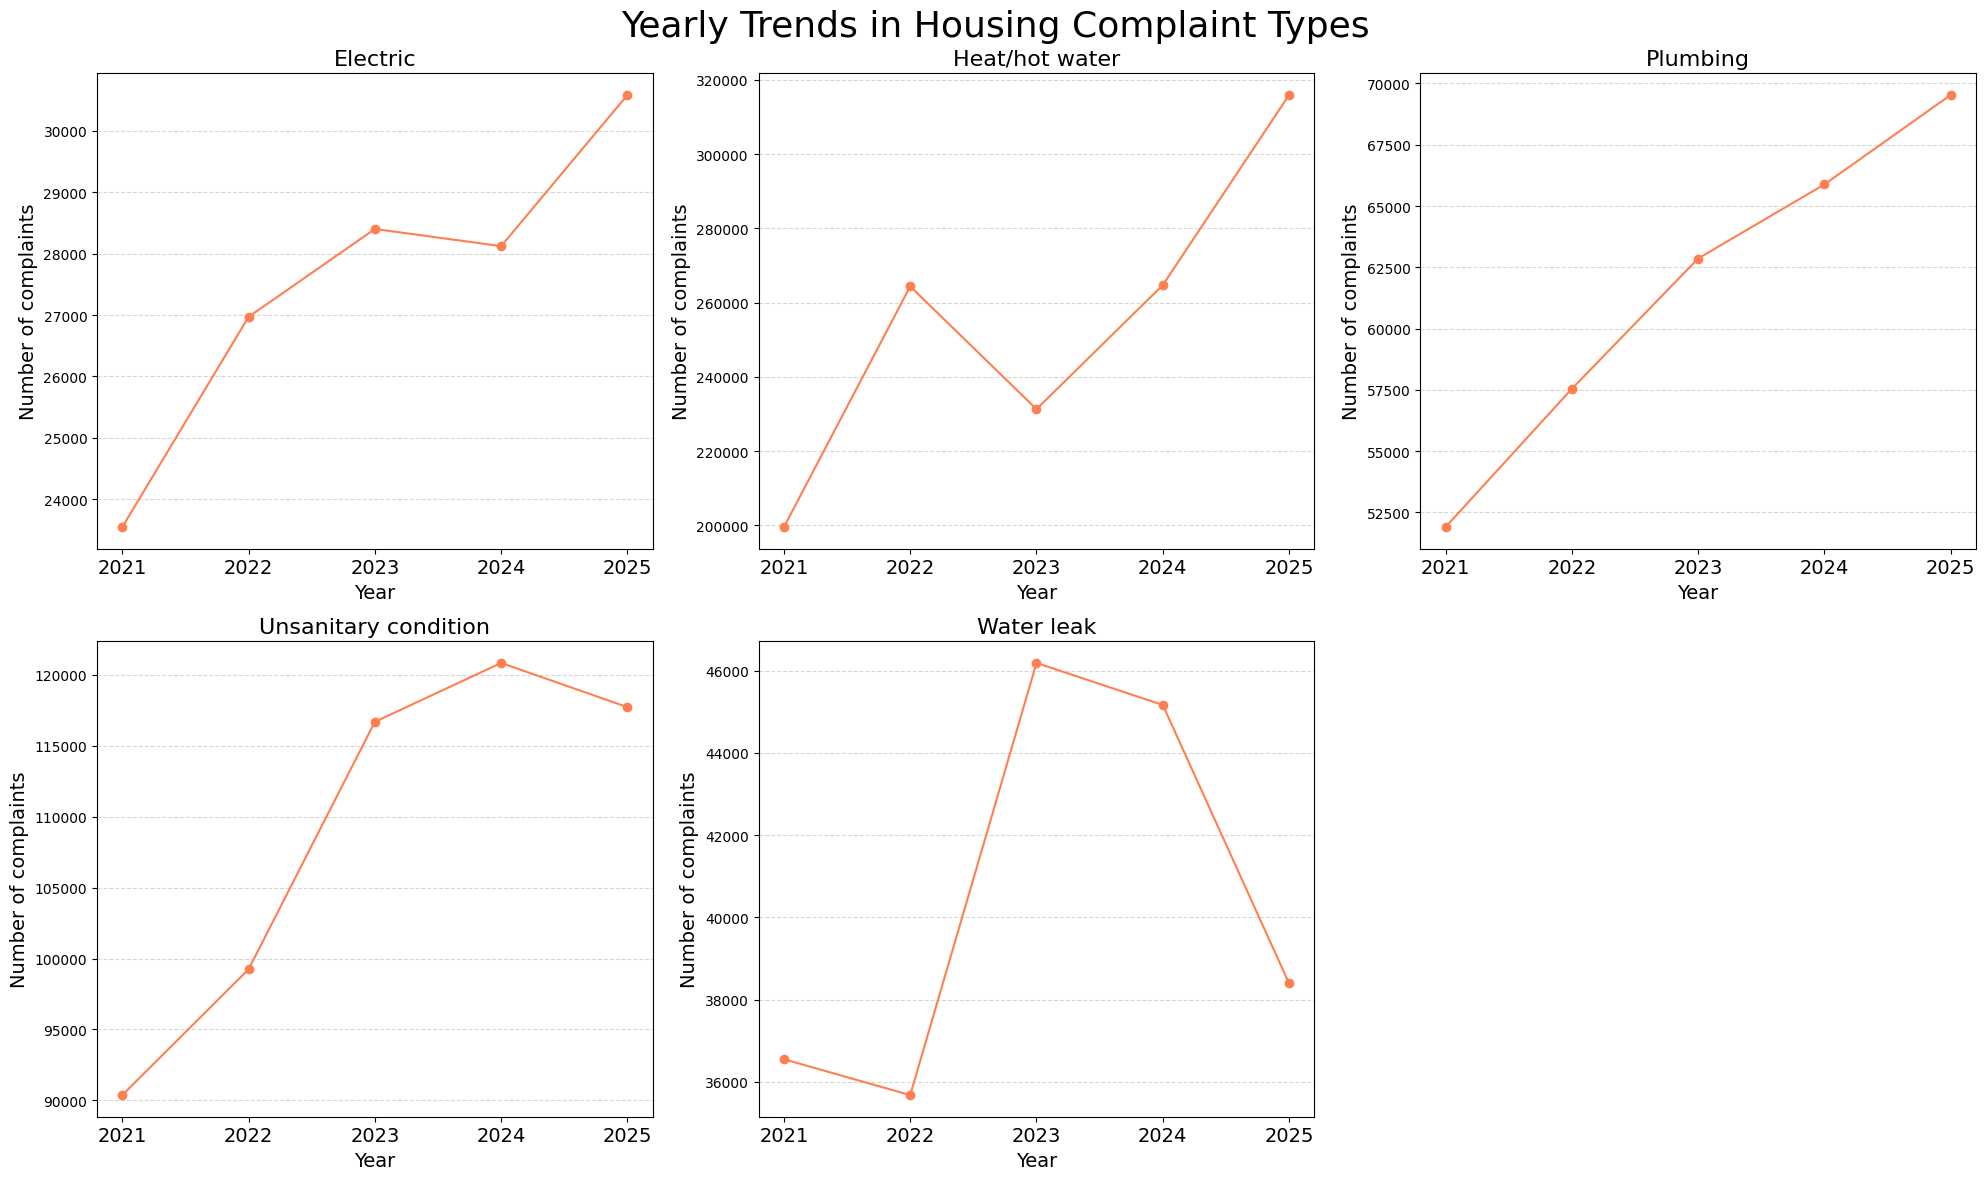

In [105]:
comp_types = year_type.columns.tolist()
years = sorted(year_type.index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cat in enumerate(comp_types):
    values = year_type[cat].values
    axes[i].plot(years, values, color="coral", marker='o')
    axes[i].set_title(cat.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(comp_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Yearly Trends in Housing Complaint Types", fontsize=26)
plt.tight_layout()
plt.show()


In [9]:
year_boro = df_complaints.groupby(["year", "borough"]).size().unstack(fill_value=0)
print(year_boro)
year_boro_norm = year_boro.div(borough_pop, axis=1) * 1000
print(year_boro_norm)

borough   BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND
year                                                       
2021     138143    119800      85022   51747           7203
2022     170131    139217     102777   63158           8528
2023     168318    138601     105276   63823           9426
2024     184587    147865     111768   72283           8226
2025     199083    159275     131122   74235           8436
borough       BRONX   BROOKLYN  MANHATTAN     QUEENS  STATEN ISLAND
year                                                               
2021      95.482545  45.233971  51.897080  22.206201      14.785848
2022     117.592211  52.565423  62.734659  27.103006      17.505722
2023     116.339090  52.332834  64.260038  27.388378      19.349078
2024     127.584000  55.830727  68.222729  31.018820      16.885796
2025     137.603436  60.138904  80.036331  31.856482      17.316870


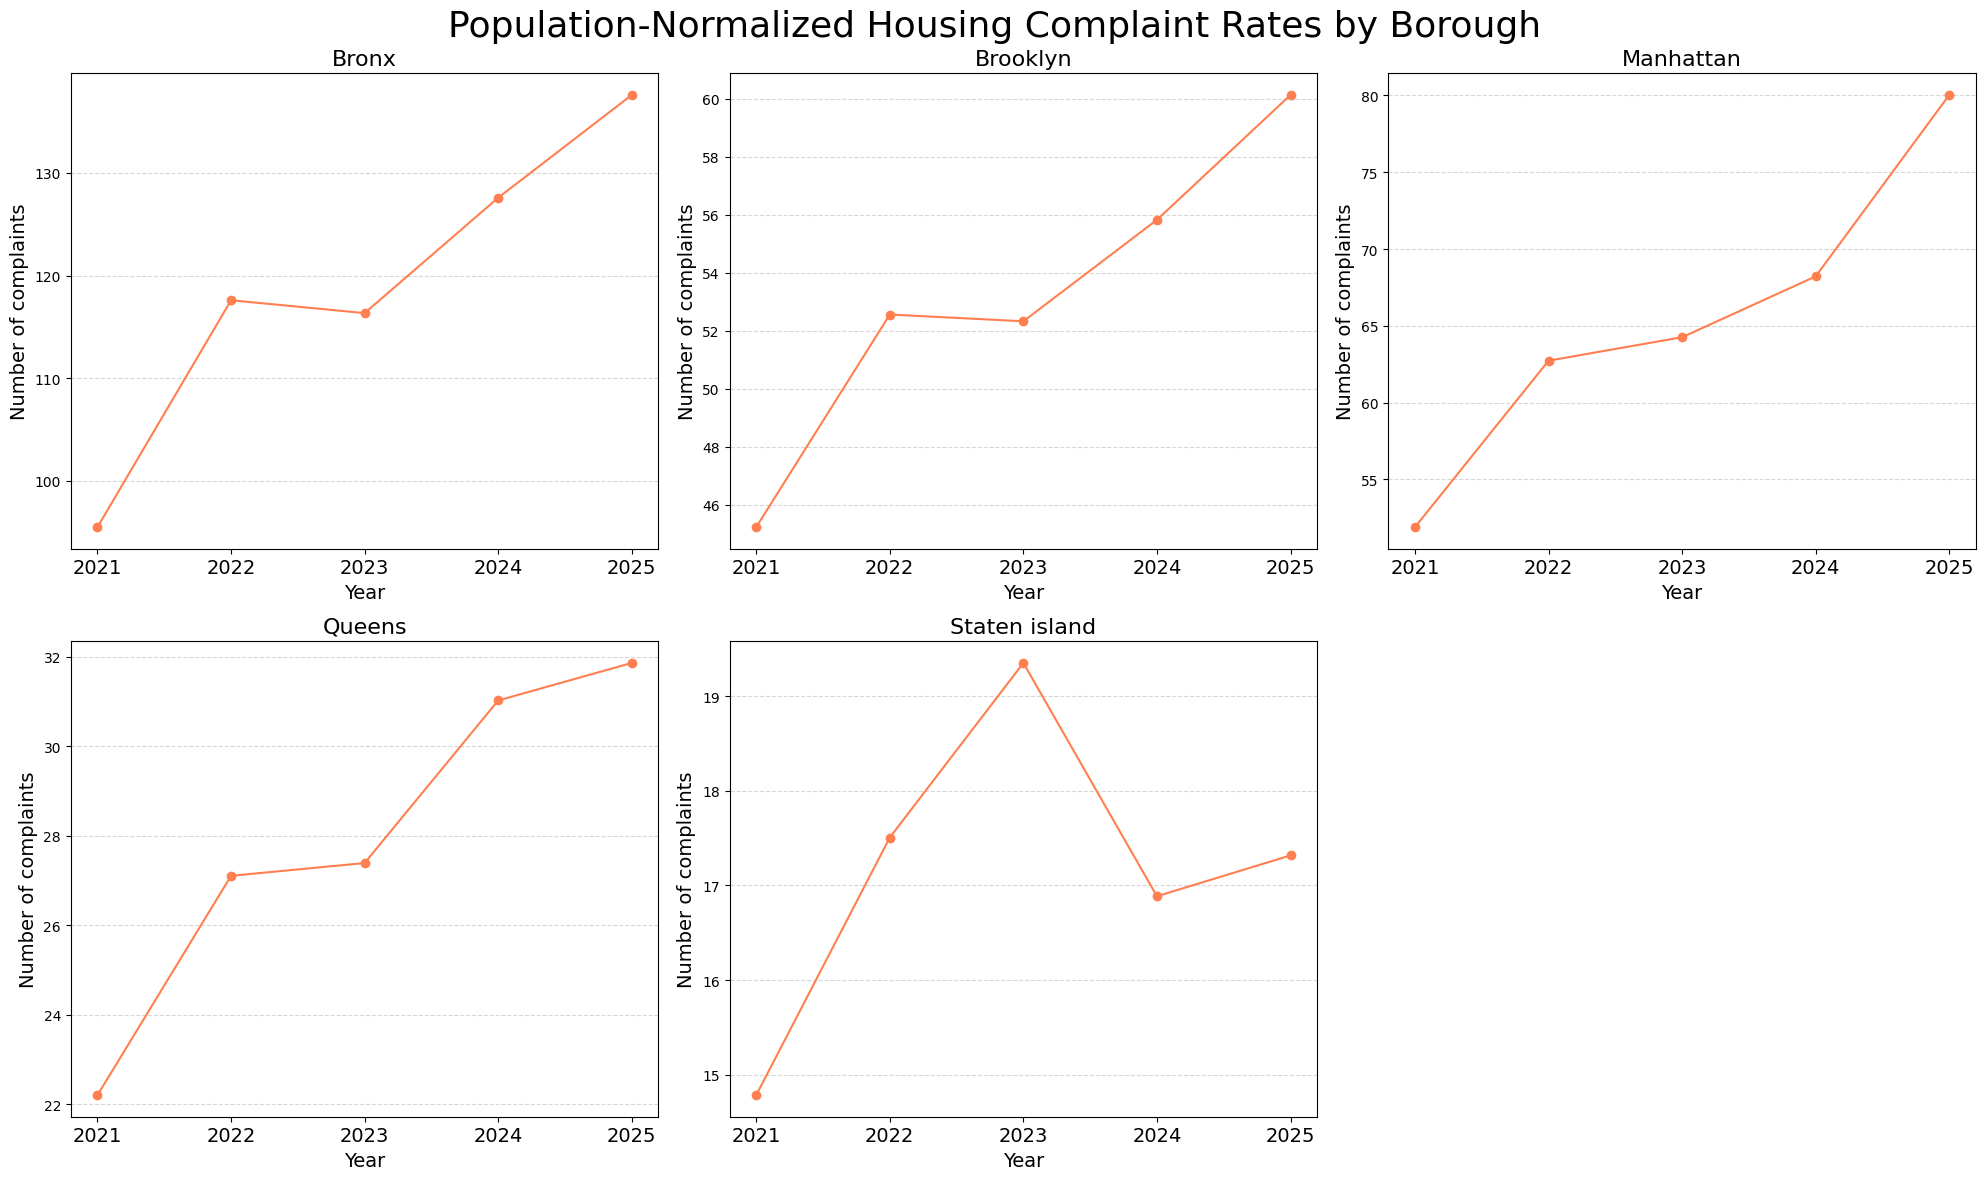

In [109]:
boroughs = year_boro.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    axes[i].plot(
        year_boro_norm.index,
        year_boro_norm[borough],
        marker='o',
        color='coral'
    )
    axes[i].set_title(borough.capitalize(), fontsize=16)
    axes[i].set_xlabel("Year", fontsize=14)
    axes[i].set_xticks(years)
    axes[i].set_xticklabels(years, fontsize=14)
    axes[i].set_ylabel("Number of complaints", fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remove the unused subplot
for j in range(len(comp_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Population‑Normalized Housing Complaint Rates by Borough", fontsize=26)
plt.tight_layout()
plt.show()


In [ ]:
grouped = (df_complaints.groupby(["borough", "year", "complaint_type"]).size().reset_index(name="count"))

,borough,year,complaint_type,count
0,BRONX,2021,ELECTRIC,7615
1,BRONX,2021,HEAT/HOT WATER,69800
2,BRONX,2021,PLUMBING,17868
3,BRONX,2021,UNSANITARY CONDITION,30457
4,BRONX,2021,WATER LEAK,12403
...,...,...,...,...
120,STATEN ISLAND,2025,ELECTRIC,679
121,STATEN ISLAND,2025,HEAT/HOT WATER,3189
122,STATEN ISLAND,2025,PLUMBING,1391
123,STATEN ISLAND,2025,UNSANITARY CONDITION,2547


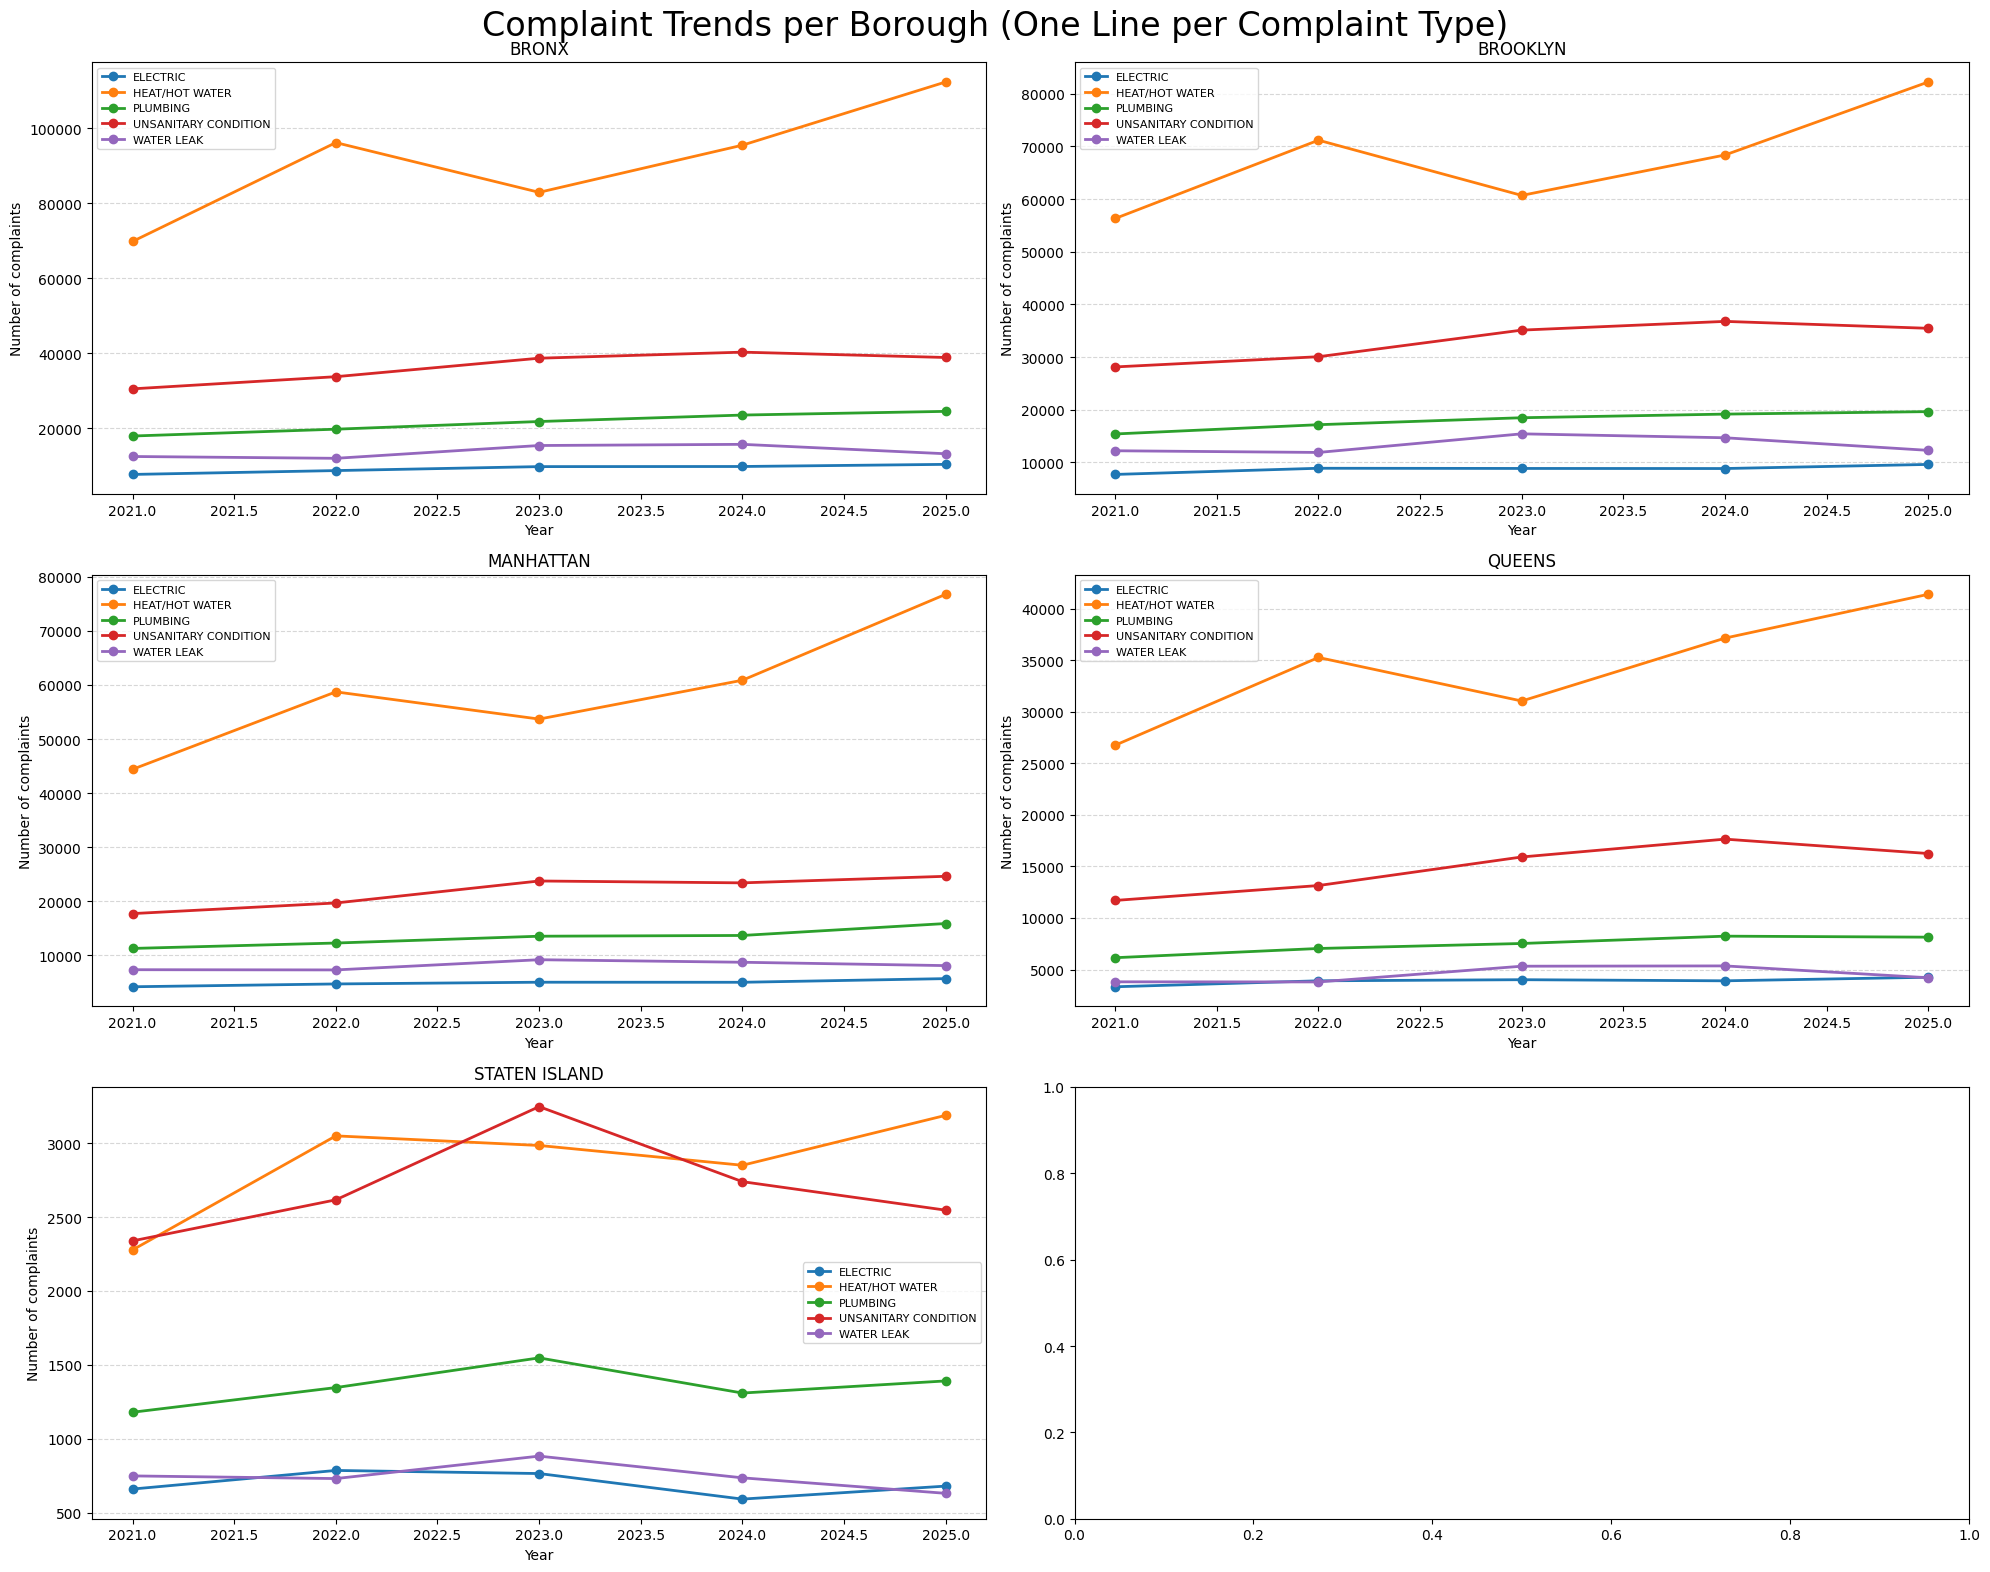

In [21]:
boroughs = grouped["borough"].unique()

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()

for i, borough in enumerate(boroughs):
    df_b = grouped[grouped["borough"] == borough]

    for comp_type in df_b["complaint_type"].unique():
        df_t = df_b[df_b["complaint_type"] == comp_type]

        axes[i].plot(
            df_t["year"],
            df_t["count"],
            marker='o',
            linewidth=2,
            label=comp_type
        )

    axes[i].set_title(borough)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Borough (One Line per Complaint Type)", fontsize=24)
plt.tight_layout()
plt.show()


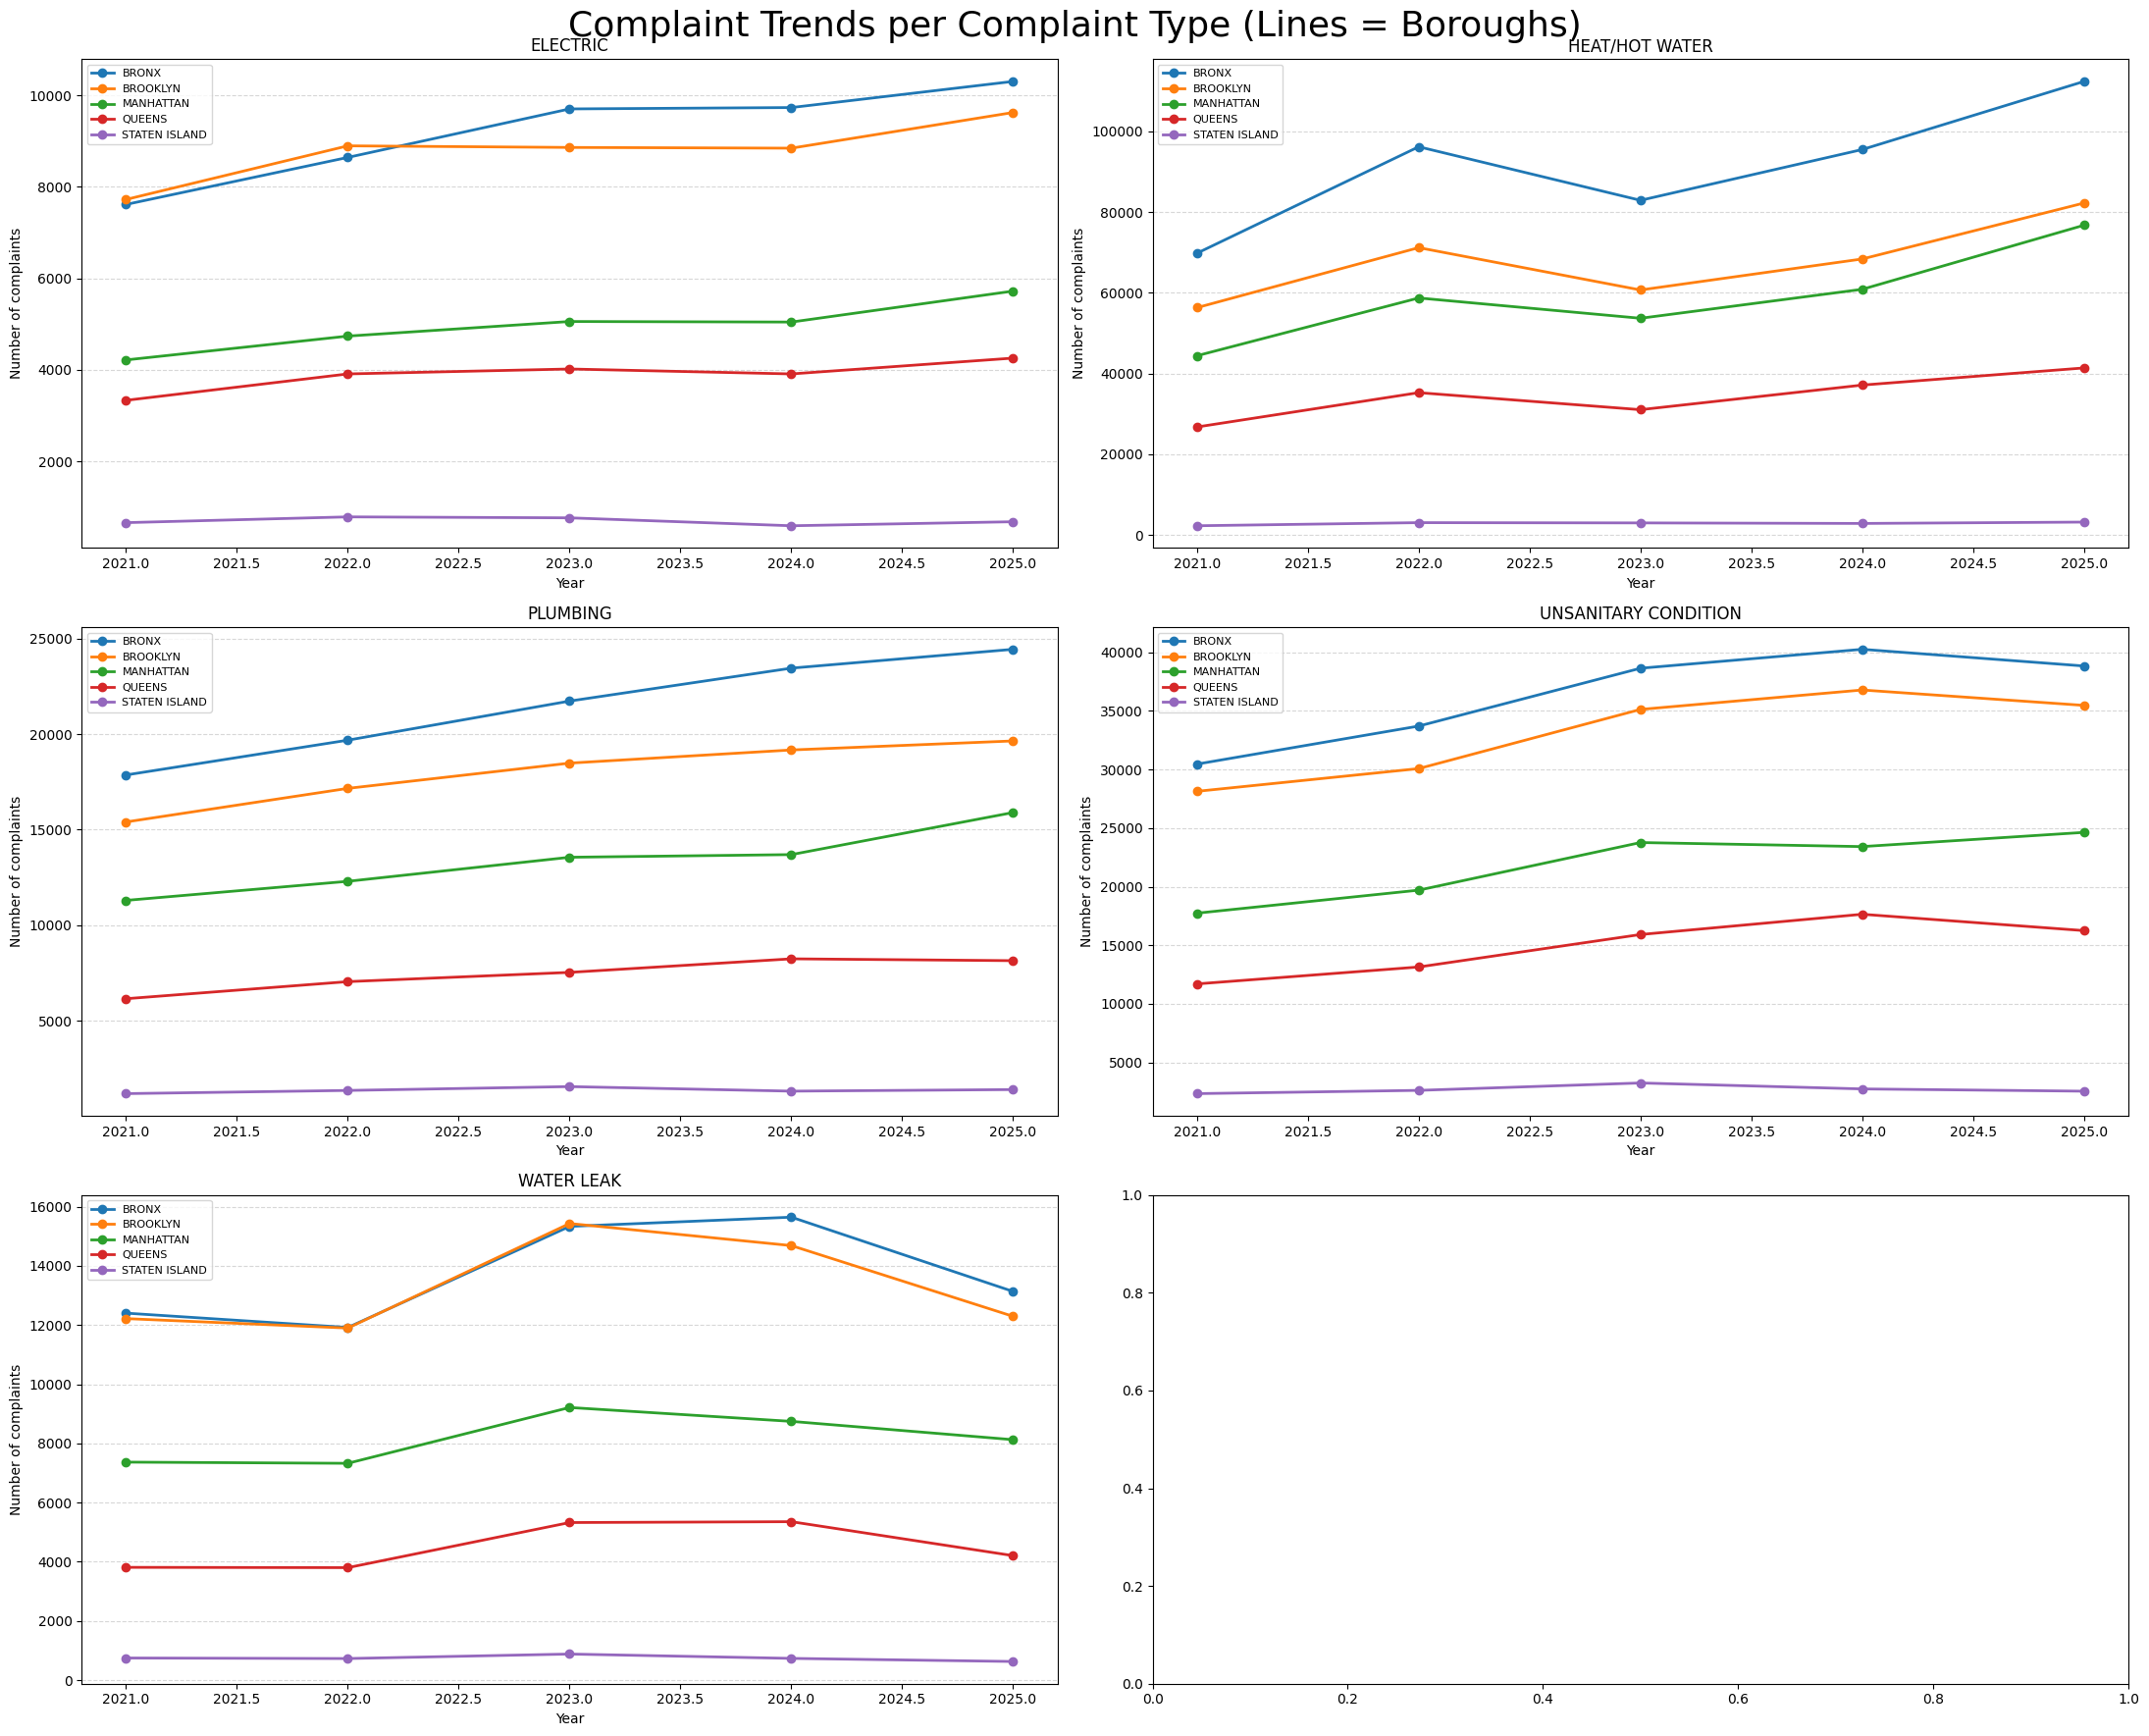

In [24]:
complaints = grouped["complaint_type"].unique()

fig, axes = plt.subplots(3, 2, figsize=(22, 18))  # adjust grid if needed
axes = axes.flatten()

for i, comp in enumerate(complaints):
    df_c = grouped[grouped["complaint_type"] == comp]

    for borough in df_c["borough"].unique():
        df_b = df_c[df_c["borough"] == borough]

        axes[i].plot(
            df_b["year"],
            df_b["count"],
            marker='o',
            linewidth=2,
            label=borough
        )

    axes[i].set_title(comp)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Number of complaints")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].legend(fontsize=8)

plt.suptitle("Complaint Trends per Complaint Type (Lines = Boroughs)", fontsize=26)
plt.tight_layout()
plt.show()


## 3. Proportionality of trend types across boroughs

Probability of complaint type in whole dataset

In [25]:
p_type=df_complaints["complaint_type"].value_counts(normalize=True)
p_type

complaint_type
HEAT/HOT WATER          0.516956
UNSANITARY CONDITION    0.220763
PLUMBING                0.124683
WATER LEAK              0.081834
ELECTRIC                0.055764
Name: proportion, dtype: float64

Probability of complaint type in district

In [28]:
p_type_boro=(df_complaints.groupby("borough")["complaint_type"].value_counts(normalize=True))
p_type_boro = p_type_boro.unstack()
p_type_boro

complaint_type,ELECTRIC,HEAT/HOT WATER,PLUMBING,UNSANITARY CONDITION,WATER LEAK
borough,,,,,
BRONX,0.053470,0.530937,0.124621,0.211419,0.079553
BROOKLYN,0.062363,0.480751,0.127544,0.234944,0.094397
MANHATTAN,0.046223,0.549303,0.124547,0.203838,0.076089
QUEENS,0.059730,0.527465,0.114080,0.229540,0.069185
STATEN ISLAND,0.083168,0.343217,0.161936,0.322605,0.089074


In [29]:
ratio = p_type_boro.div(p_type, axis=1)

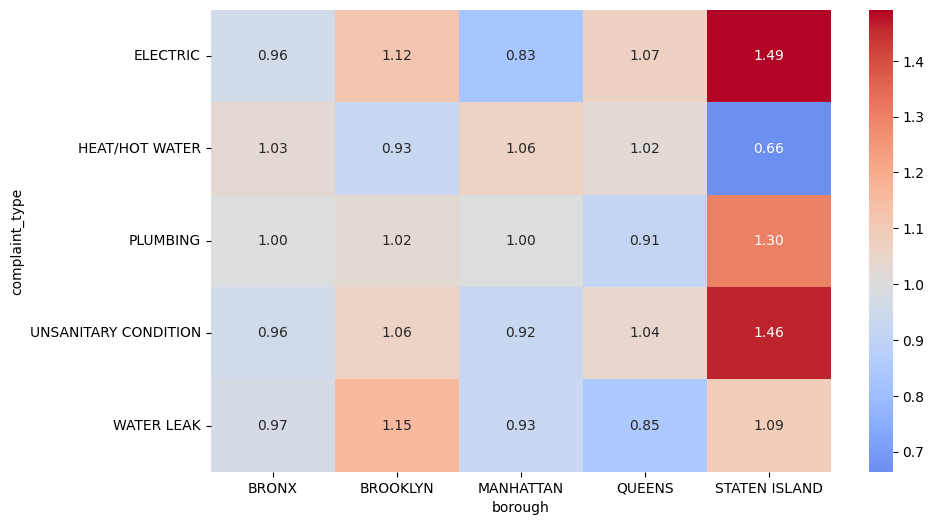

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(ratio.T, cmap="coolwarm", center=1, annot=True, fmt=".2f")
plt.show()

In [32]:
df_complaints.head()

,unique_key,created_date,complaint_type,incident_zip,council_district,borough,year
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229,46,BROOKLYN,2025
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239,42,BROOKLYN,2025
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040,10,MANHATTAN,2025
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463,10,MANHATTAN,2025
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454,8,BRONX,2025


## 4. Calendar plot

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


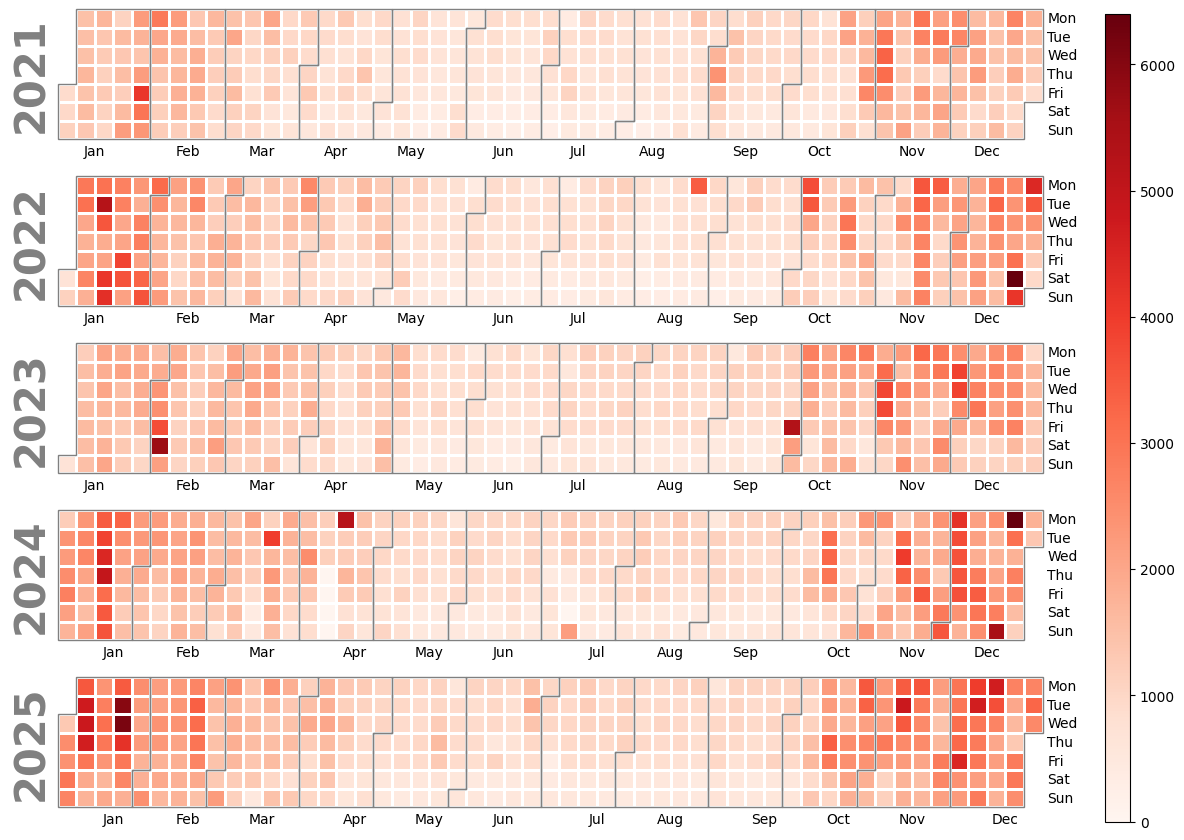

In [110]:
df_complaints["date"] = df_complaints["created_date"].dt.floor("D")
daily_counts = df_complaints.groupby("date").size()
calplot.calplot(daily_counts, cmap='Reds')
plt.show()

# Violations

add borough

In [113]:
df_violations=pd.read_csv("data/violations20_25_original.csv")
print(df_violations.isna().sum())
df_violations.head()

violationid              0
zip                      0
class                    0
inspectiondate           0
originalcorrectbydate    0
newcorrectbydate         0
certifieddate            0
councildistrict          0
dtype: int64


,violationid,zip,class,inspectiondate,originalcorrectbydate,newcorrectbydate,certifieddate,councildistrict
0,18550590,10460,C,2025-12-31,2026-01-29T00:00:00.000,2026-02-12T00:00:00.000,2026-02-03T00:00:00.000,15
1,18555866,10467,C,2025-12-30,2026-01-29T00:00:00.000,2026-02-26T00:00:00.000,2026-03-03T00:00:00.000,13
2,18555864,10467,C,2025-12-30,2026-01-29T00:00:00.000,2026-02-26T00:00:00.000,2026-03-03T00:00:00.000,13
3,18555867,10467,C,2025-12-30,2026-01-29T00:00:00.000,2026-02-26T00:00:00.000,2026-03-03T00:00:00.000,13
4,18555861,10467,C,2025-12-30,2026-01-29T00:00:00.000,2026-02-26T00:00:00.000,2026-03-03T00:00:00.000,13


In [115]:
print(f"Number of violations: {len(df_violations)}")

df_violations["inspectiondate"]=pd.to_datetime(df_violations["inspectiondate"]) #add smth for errors
print(f"Date range: {df_violations["inspectiondate"].min()}, {df_violations["inspectiondate"].max()}")

Number of violations: 11262
Date range: 2021-01-03 00:00:00, 2025-12-31 00:00:00


In [ ]:


unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different council districts: {len(df_complaints["council_district"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")